When looking at the coefficient of birth year, the age window 55-60 showed extreme values in every region. this is a debug to see if the age window is valid (contains any outliers)

In [22]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from tqdm import tqdm

combined_df = pd.read_pickle('/home/gaia/Projects/legacy_data/combined_gm_volumes.pkl')
 
# keep only classification_label=1 and snbb
volumes = combined_df[(combined_df['classification_label'] == 1) | (combined_df['source'] == 'snbb')]

volumes['age_in_years'] = pd.to_numeric(volumes['age_in_years'], errors='coerce')

# divide volumes into age bins according to bin size
bin_size = 5
volumes['age_bin'] = pd.cut(volumes['age_in_years'], bins=np.arange(15, 85, bin_size))




/tmp/ipykernel_15547/2153569491.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  volumes['age_in_years'] = pd.to_numeric(volumes['age_in_years'], errors='coerce')
/tmp/ipykernel_15547/2153569491.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  volumes['age_bin'] = pd.cut(volumes['age_in_years'], bins=np.arange(15, 85, bin_size))


In [23]:
subjects_per_bin = volumes.groupby('age_bin')['subject_id'].nunique()
print(f"number of unique subjects in each age bin:")
print(subjects_per_bin)

number of unique subjects in each age bin:
age_bin
(15, 20]     107
(20, 25]    1034
(25, 30]    1062
(30, 35]     565
(35, 40]     307
(40, 45]     221
(45, 50]     138
(50, 55]      94
(55, 60]      84
(60, 65]      76
(65, 70]      48
(70, 75]      25
(75, 80]      11
Name: subject_id, dtype: int64


/tmp/ipykernel_15547/1438605394.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subjects_per_bin = volumes.groupby('age_bin')['subject_id'].nunique()


In [24]:
print(volumes.columns)

Index(['subject_id', 'session_id', 'region_label', 'tissue_type', 'volume_mm3',
       'tiv', 'sex', 'institute', 'manufacturer', 'age_in_years', 'dob',
       'gm_volume_cm3', 'protocol', 'source', 'birth_year', 'Unnamed: 0',
       'atlas_name', 'scan_time', 'age_at_scan', 'weight', 'directory_path',
       'estimated_critical_info', 'scan_date', 'file_path',
       'classification_label', 'age_bin'],
      dtype='object')


In [25]:
late_fifties_df = volumes[(volumes['age_in_years'] >= 55) & (volumes['age_in_years'] < 60)].copy()

subjects_late_fifties = late_fifties_df['subject_id'].unique()
print(f"Number of subjects in late fifties: {len(subjects_late_fifties)}")

# compare late fifties to early thirties 
early_thirties_df = volumes[(volumes['age_in_years'] >= 30) & (volumes['age_in_years'] < 35)].copy()
subjects_early_thirties = early_thirties_df['subject_id'].unique()
print(f"Number of subjects in early thirties: {len(subjects_early_thirties)}")

# define relevant regions for testing
random_regions = [421]  # for consistent results during testing

# generate n random regions between 1 to 454
region_list = np.arange(1, 455)
n = 5
random_regions = np.random.choice(region_list, n, replace=False)

Number of subjects in late fifties: 81
Number of subjects in early thirties: 585


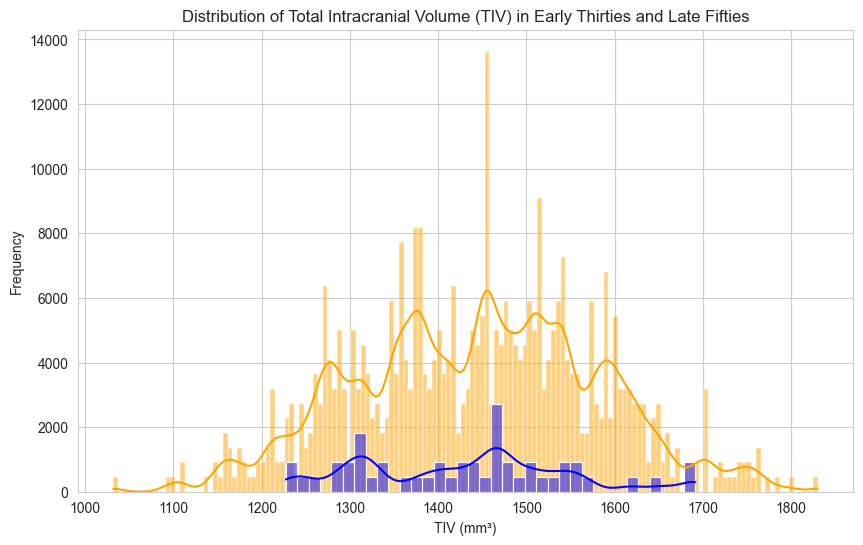

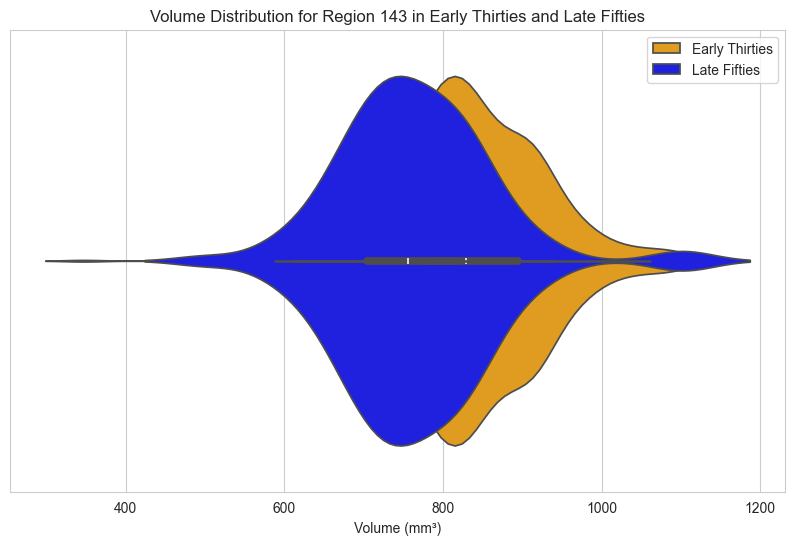

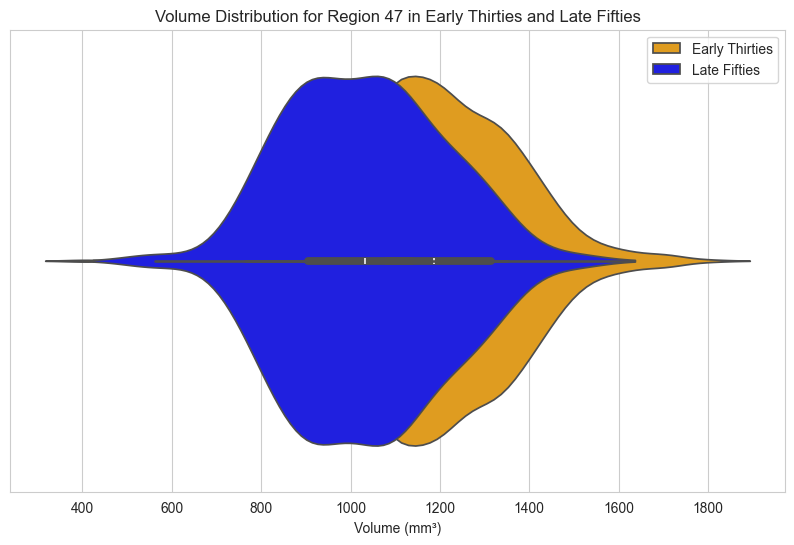

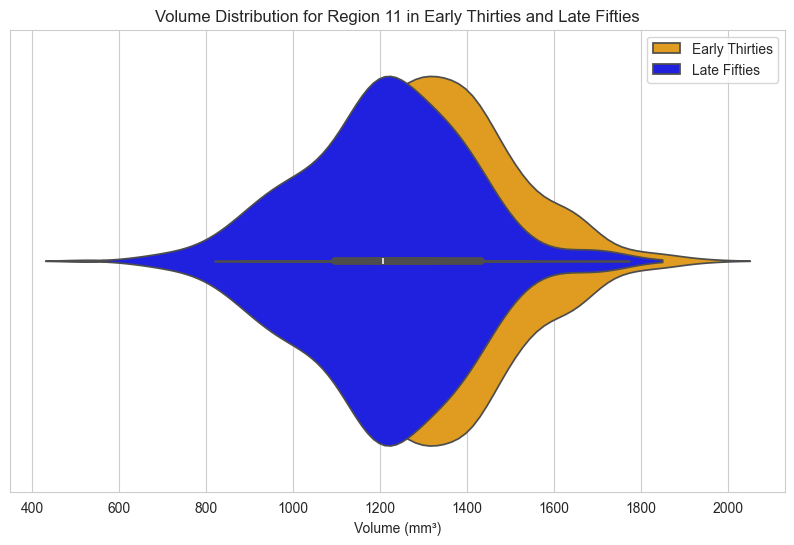

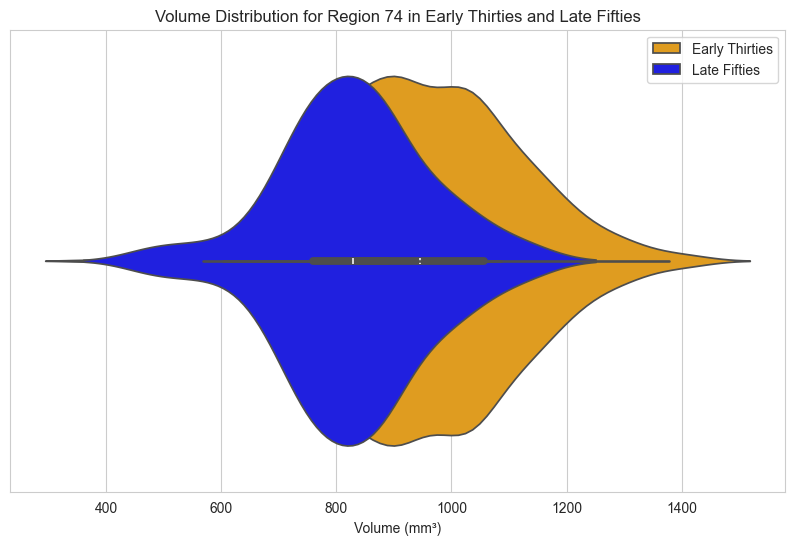

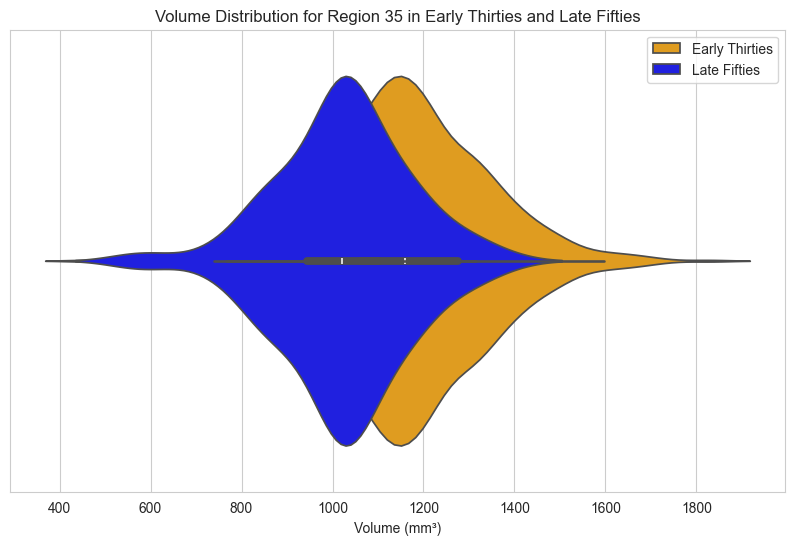

In [26]:
# plot tiv distribution
plt.figure(figsize=(10, 6))
sns.histplot(early_thirties_df['tiv'], kde=True, color='orange')
sns.histplot(late_fifties_df['tiv'], kde=True, color='blue')
plt.title('Distribution of Total Intracranial Volume (TIV) in Early Thirties and Late Fifties')
plt.xlabel('TIV (mm³)')
plt.ylabel('Frequency')
plt.show()


# plot volume_mm3 distribution for random regions, violin plot
for region in random_regions:
    region_early_df = early_thirties_df[early_thirties_df['region_label'] == region]
    region_late_df = late_fifties_df[late_fifties_df['region_label'] == region]
    plt.figure(figsize=(10, 6))
    sns.violinplot(x=region_early_df['volume_mm3'], color='orange', label='Early Thirties')
    sns.violinplot(x=region_late_df['volume_mm3'], color='blue', label='Late Fifties')
    plt.title(f'Volume Distribution for Region {region} in Early Thirties and Late Fifties')
    plt.xlabel('Volume (mm³)')
    plt.legend()
    plt.show()

In [27]:
late_fifties_df.describe()

,region_label,volume_mm3,tiv,age_in_years,gm_volume_cm3,birth_year,Unnamed: 0,scan_time,weight,scan_date,classification_label
count,39952.000000,39952.000000,21792.000000,39952.000000,21792.000000,39952.000000,0.0,18160.000000,18160.000000,1.816000e+04,18160.0
mean,227.500000,1069.689504,1429.573333,57.309432,498036.291909,1960.113636,NaN,1175.000000,73.250000,2.010762e+07,1.0
std,131.059833,569.765077,116.634851,1.454501,41843.747827,7.243319,NaN,237.975563,13.843701,5.253250e+04,0.0
min,1.000000,4.427198,1227.520000,55.000000,406934.043881,1944.000000,NaN,813.000000,50.000000,2.001091e+07,1.0
25%,114.000000,656.094813,1321.942500,56.000000,466229.178288,1955.000000,NaN,1011.250000,62.250000,2.007040e+07,1.0
50%,227.500000,973.075731,1441.765000,57.110000,501635.058266,1963.000000,NaN,1102.500000,71.000000,2.013112e+07,1.0
75%,341.000000,1371.344056,1503.470000,58.727500,520305.433514,1966.000000,NaN,1336.250000,83.000000,2.015074e+07,1.0
max,454.000000,4201.350161,1691.330000,59.850000,607058.905515,1970.000000,NaN,1729.000000,104.000000,2.018053e+07,1.0


In [28]:
early_thirties_df.describe()

,region_label,volume_mm3,tiv,age_in_years,gm_volume_cm3,birth_year,Unnamed: 0,scan_time,weight,scan_date,classification_label
count,357298.000000,357298.000000,357298.000000,357298.000000,289652.000000,357298.000000,0.0,67646.000000,67646.000000,6.764600e+04,67646.0
mean,227.500000,1201.766691,1443.918183,32.069492,548130.701420,1988.576874,NaN,1240.496644,70.389262,2.011435e+07,1.0
std,131.058377,633.707237,136.933223,1.467369,49121.051349,5.034084,NaN,344.698847,14.959434,4.236010e+04,0.0
min,1.000000,1.953100,1031.780000,30.000000,399390.615783,1971.000000,NaN,732.000000,47.000000,2.005032e+07,1.0
25%,114.000000,743.067204,1347.570000,30.750000,512584.352769,1988.000000,NaN,931.000000,60.000000,2.008042e+07,1.0
50%,227.500000,1097.513596,1452.700000,32.000000,551461.672283,1990.000000,NaN,1147.000000,70.000000,2.010031e+07,1.0
75%,341.000000,1539.628305,1539.460000,33.280000,582381.284117,1992.000000,NaN,1505.000000,80.000000,2.015123e+07,1.0
max,454.000000,5549.050898,1830.130000,34.990000,682465.676253,1995.000000,NaN,2225.000000,121.000000,2.018050e+07,1.0


# coefficiant distributions

In [29]:
coef_df = pd.read_csv("/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/coef_df_age_bins_size_5.csv")


In [30]:
print(coef_df.columns)

test = coef_df['coef'][coef_df['variable'] == 'birth_year']

Index(['age_bin', 'region_label', 'variable', 'coef', 't', 'p', 'fdr_p',
       'region_name'],
      dtype='object')


/tmp/ipykernel_15547/3909780055.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  plot = sns.kdeplot(
/tmp/ipykernel_15547/3909780055.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Age Bin')


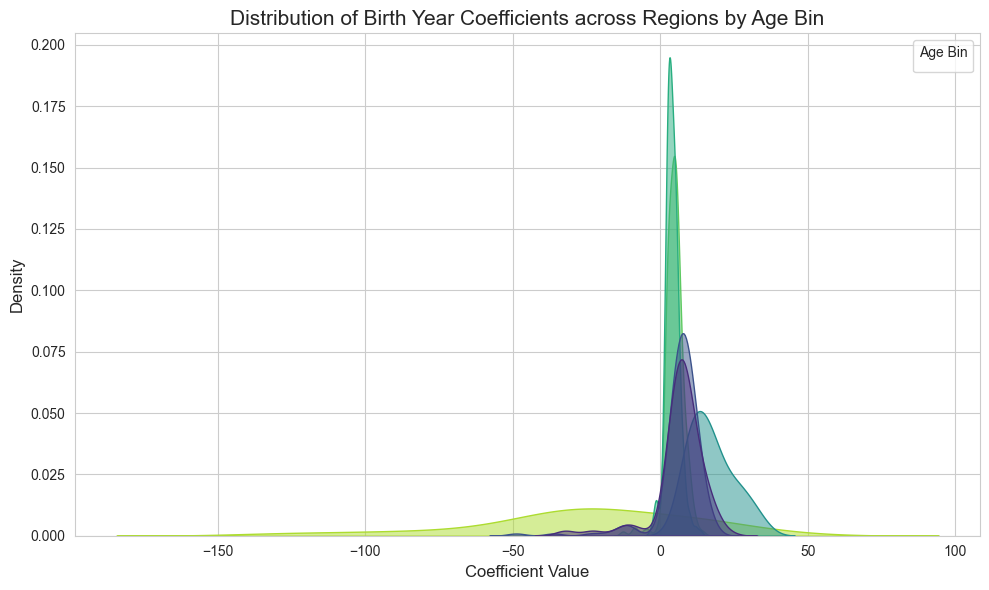

In [31]:

# plot the birth year coefficient distribution of all regions, present all in one plot, color code by age bin
# standarize frequency by age_bin size
plot_data =  coef_df[(coef_df['variable'] == 'birth_year') & (coef_df['fdr_p'] < 0.05)]


# 3. Create the plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# We use a KDE (Kernel Density Estimate) plot to show the distribution
# 'hue' handles the color coding by age_bin
plot = sns.kdeplot(
    data=plot_data, 
    x='coef', 
    hue='age_bin', 
    fill=True, 
    palette='viridis',
    common_norm=False, # This ensures each age bin's density is normalized independently
    alpha=0.5
)

plt.title('Distribution of Birth Year Coefficients across Regions by Age Bin', fontsize=15)
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Age Bin')

plt.tight_layout()
plt.savefig('coefficient_distribution.png')
plt.show()

In [32]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = plot_data['coef'].quantile(0.25)
Q3 = plot_data['coef'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Extract the outliers
outliers = plot_data[(plot_data['coef'] < lower_bound) | (plot_data['coef'] > upper_bound)]

# Sort them to see the most extreme values first
outliers_sorted = outliers.sort_values(by='coef')

print(f"Total outliers found: {len(outliers)}")
print(outliers_sorted[['region_name', 'age_bin', 'coef', 't', 'p']])

Total outliers found: 74
                          region_name   age_bin        coef         t  \
24970  7Networks_RH_Limbic_TempPole_1  (40, 45] -125.642090 -6.535306   
24971  7Networks_LH_Limbic_TempPole_1  (40, 45]  -95.699110 -5.501577   
24972  7Networks_RH_Limbic_TempPole_2  (40, 45]  -76.044287 -5.282247   
24975  7Networks_RH_Limbic_TempPole_4  (40, 45]  -56.648724 -4.367299   
2280   7Networks_RH_Limbic_TempPole_1  (25, 30]  -48.873904 -6.344484   
...                               ...       ...         ...       ...   
18162          7Networks_RH_SomMot_25  (15, 20]   24.727088  4.755422   
18160                       THA-DP-lh  (15, 20]   26.497835  5.240413   
18170     7Networks_LH_Default_Temp_7  (15, 20]   32.109979  3.349795   
24973          7Networks_LH_SomMot_27  (40, 45]   35.613887  4.582151   
6810            7Networks_RH_SomMot_7  (65, 70]   41.030161  4.665138   

                  p  
24970  3.257209e-10  
24971  8.894860e-08  
24972  2.670841e-07  
24975  1.8